# Rekomendasi Jurusan Kuliah

## Dataset

In [38]:
import pandas as pd

data = {
    'mtk': [90, 85, 70, 60, 88, 92, 75, 65, 82, 78],
    'ipa': [85, 80, 75, 65, 90, 95, 70, 60, 78, 72],
    'inggris': [80, 82, 78, 85, 88, 90, 75, 80, 83, 79],
    'minat_teknologi': [9, 8, 6, 3, 9, 10, 5, 2, 7, 6],
    'minat_sosial': [3, 4, 7, 9, 2, 1, 8, 9, 5, 6],
    'jurusan': [
        'TI', 'TI', 'Manajemen', 'Hukum',
        'TI', 'Kedokteran', 'Manajemen', 'Hukum',
        'Kedokteran', 'Manajemen'
    ]
}

jurusan_df = pd.DataFrame(data)
jurusan_df

,mtk,ipa,inggris,minat_teknologi,minat_sosial,jurusan
0,90,85,80,9,3,TI
1,85,80,82,8,4,TI
2,70,75,78,6,7,Manajemen
3,60,65,85,3,9,Hukum
4,88,90,88,9,2,TI
5,92,95,90,10,1,Kedokteran
6,75,70,75,5,8,Manajemen
7,65,60,80,2,9,Hukum
8,82,78,83,7,5,Kedokteran
9,78,72,79,6,6,Manajemen


## Visualisasi

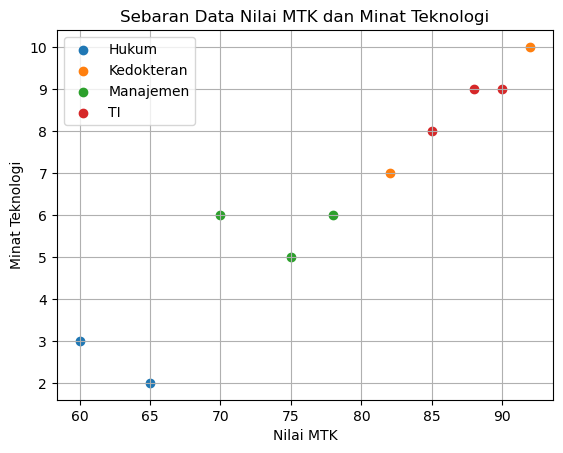

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for jurusan, d in jurusan_df.groupby('jurusan'):
    ax.scatter(d['mtk'], d['minat_teknologi'], label=jurusan)

plt.legend()
plt.title('Sebaran Data Nilai MTK dan Minat Teknologi')
plt.xlabel('Nilai MTK')
plt.ylabel('Minat Teknologi')
plt.grid(True)
plt.show()

## Split X dan Y

In [40]:
import numpy as np

X = np.array(jurusan_df[['mtk', 'ipa', 'inggris', 'minat_teknologi', 'minat_sosial']])
y = np.array(jurusan_df['jurusan'])

## Encoding

In [41]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y = lb.fit_transform(y)

## Model KNN

In [42]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Akurasi

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train ulang model
model.fit(X_train, y_train)

# Prediksi data test
y_pred = model.predict(X_test)

# Hitung akurasi
acc = accuracy_score(y_test, y_pred)
print("Akurasi model:", acc * 100 ,"%")

Akurasi model: 50.0 %


## Prediksi

In [44]:
# Urutan Array Input = MTK, IPA, Inggris, Minat Teknologi, Minat Sosial
data_baru = np.array([[85, 80, 82, 8, 4]])
hasil = model.predict(data_baru)

# Urutan Array Output = Hukum, Kedokteran, Manajemen, TI
print("Hasil (encoded):", hasil)
print("Rekomendasi jurusan:", lb.inverse_transform(hasil))

Hasil (encoded): [[0 0 0 1]]
Rekomendasi jurusan: ['TI']
